In [ ]:
import numpy as np

def auditory_filter(f, CF, BW, n=10):
    """
    Python translation of the MATLAB function.

    Parameters
    ----------
    f : ndarray
        Frequency vector
    CF : float
        Center frequency
    BW : float
        Bandwidth
    n : int
        Filter order (default = 10)

    Returns
    -------
    Sn : ndarray
        Spectral weighting
    """

    gamma_n = 1.0

    # compute lambda_n
    for _ in range(2, n+1):
        gamma_n = np.log(gamma_n + 1)

    lambda_n = np.sqrt(gamma_n)

    # shift filter
    f = f - CF

    f = lambda_n * f / BW

    Gamma_n = np.exp(f**2)

    # compute Gamma_n
    for _ in range(2, n+1):
        Gamma_n = np.exp(Gamma_n - 1)

    Sn = 1.0 / Gamma_n

    return Sn

C:\Users\setht\AppData\Local\Temp\ipykernel_1124\2451670164.py:41: RuntimeWarning: overflow encountered in exp
  Gamma_n = np.exp(Gamma_n - 1)


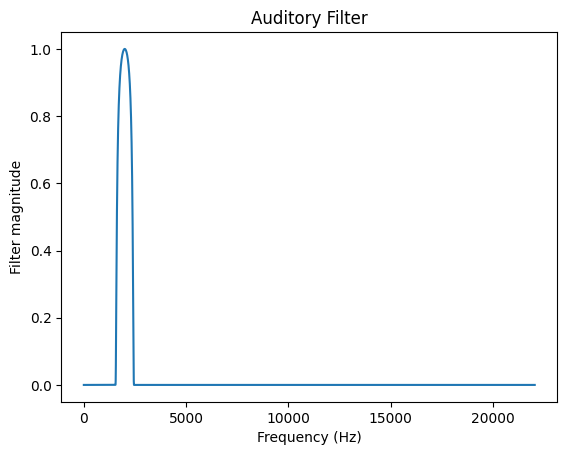

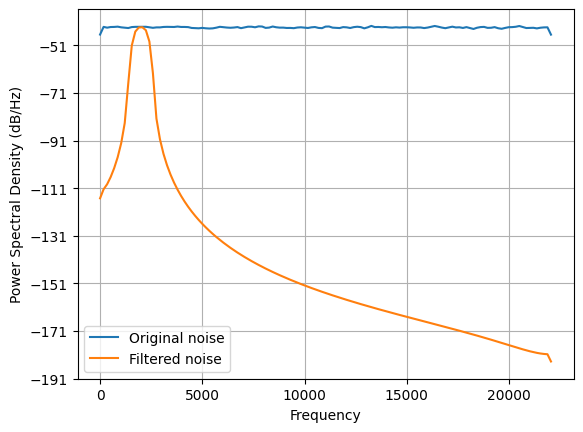

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 44100
duration = 2.0
N = int(fs * duration)

CF = 2000     # center frequency
BW = 400      # bandwidth
n = 10

# Generate white noise
noise = np.random.randn(N)

# FFT
freqs = np.fft.rfftfreq(N, 1/fs)
Noise_fft = np.fft.rfft(noise)

# Compute filter
Sn = auditory_filter(freqs, CF, BW, n)

# Apply filter
Filtered_fft = Noise_fft * Sn

# Back to time domain
filtered_noise = np.fft.irfft(Filtered_fft, N)

# Plot filter
plt.figure()
plt.plot(freqs, Sn)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Filter magnitude")
plt.title("Auditory Filter")
plt.show()

# Compare spectra
plt.figure()
plt.psd(noise, Fs=fs)
plt.psd(filtered_noise, Fs=fs)
plt.legend(["Original noise", "Filtered noise"])
plt.show()

In [1]:


import numpy as np
from scipy.fft import rfft, irfft, rfftfreq

def iterate(func, x, n):
    """Apply func n times."""
    for _ in range(n):
        x = func(x)
    return x

def exp_filter_vectorized(wf, fs, fmin, fmax, order=10):

    f = rfftfreq(len(wf), 1/fs)

    CF = (fmin + fmax) / 2
    BW = fmax - fmin

    # gamma_n
    gamma_n = iterate(lambda x: np.log(x + 1), 1.0, order-1)

    lambda_n = np.sqrt(gamma_n)

    x = lambda_n * (f - CF) / BW

    # Gamma_n
    Gamma_n = iterate(lambda x: np.exp(x - 1), np.exp(x**2), order-1)

    Sn = 1 / Gamma_n
    
    wf_f = rfft(wf)
    wf_filt = irfft(wf_f * Sn, n=len(wf))

    return wf_filt




def exp_filter(wf, fs, fmin, fmax, order=30):
    N = len(wf)
    f = rfftfreq(N, 1/fs)

    # Get Filter response
    CF = (fmin + fmax)/2
    BW = fmax-fmin

    gamma_n = 1.0

    # compute lambda_n
    for _ in range(2, order+1):
        gamma_n = np.log(gamma_n + 1)

    lambda_n = np.sqrt(gamma_n)

    # shift filter
    f = f - CF
    f = lambda_n * f / BW

    Gamma_n = np.exp(f**2)

    # compute Gamma_n
    for _ in range(2, order+1):
        Gamma_n = np.exp(Gamma_n - 1)

    Sn = 1.0 / Gamma_n

    # Apply in Fourier domain
    wf_f = rfft(wf)
    wf_f = wf_f*Sn
    wf_filt = irfft(wf_f)
    return wf_filt

In [2]:
N = 44100*60

wf = np.random.randn(N)

wf = exp_filter(wf, 44100, 100, 200, 30)

C:\Users\setht\AppData\Local\Temp\ipykernel_888\2529076932.py:57: RuntimeWarning: overflow encountered in exp
  Gamma_n = np.exp(f**2)
C:\Users\setht\AppData\Local\Temp\ipykernel_888\2529076932.py:61: RuntimeWarning: overflow encountered in exp
  Gamma_n = np.exp(Gamma_n - 1)


In [26]:

fs = 44100
N = fs*60
wf = np.random.randn(N)


In [29]:
def exp_filter1(wf, fs, fmin, fmax, order=30):
    safe_exp = lambda x: np.exp(np.clip(x, -50, 50))
    N = len(wf)
    f = rfftfreq(N, 1/fs)

    # Get Filter response
    CF = (fmin + fmax)/2
    BW = fmax-fmin

    gamma_n = 1.0

    # compute lambda_n
    for _ in range(2, order+1):
        gamma_n = np.log(gamma_n + 1)

    lambda_n = np.sqrt(gamma_n)

    # shift filter
    f = f - CF
    f = lambda_n * f / BW

    Gamma_n = np.exp(f**2)

    # compute Gamma_n
    for _ in range(2, order+1):
        Gamma_n = np.exp(Gamma_n - 1)

    Sn = 1.0 / Gamma_n

    # Apply in Fourier domain
    wf_f = rfft(wf)
    wf_f = wf_f*Sn
    wf_filt = irfft(wf_f)
    return wf_filt

def exp_filter2(wf, fs, fmin, fmax, order=30):
    safe_exp = lambda x: np.exp(np.clip(x, -50, 50))
    N = len(wf)
    f = rfftfreq(N, 1/fs)

    # Get Filter response
    CF = (fmin + fmax)/2
    BW = fmax-fmin

    gamma_n = 1.0

    # compute lambda_n
    for _ in range(2, order+1):
        gamma_n = np.log(gamma_n + 1)

    lambda_n = np.sqrt(gamma_n)

    # shift filter
    f = f - CF
    f = lambda_n * f / BW

    Gamma_n = safe_exp(f**2)

    # compute Gamma_n
    for _ in range(2, order+1):
        Gamma_n = safe_exp(Gamma_n - 1)

    Sn = 1.0 / Gamma_n

    # Apply in Fourier domain
    wf_f = rfft(wf)
    wf_f = wf_f*Sn
    wf_filt = irfft(wf_f)
    return wf_filt

# wf_filt1 = exp_filter1(wf, 44100, 1000, 2000, 30)
wf_filt2 = exp_filter2(wf, 44100, 1000, 2000, 30)
import matplotlib.pyplot as plt
f = rfftfreq(len(wf_filt1), 1/fs)
psd1 = np.abs(rfft(wf_filt1))
psd2 = np.abs(rfft(wf_filt2))
# plt.figure(1)
# plt.scatter(f, psd1)
# plt.scatter(f, psd2)
# plt.figure(2)
# plt.plot(f, psd1-psd2)
print(np.max(np.abs(psd1-psd2)))

9.094947017729282e-13
